In [1]:
# ==========================================
# PROJECT 2 - USED CAR PRICE
# PART 1: DATA CLEANING + FEATURE ENGINEERING
# ==========================================

import pandas as pd
import numpy as np

# ------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------

df = pd.read_csv("used_cars.csv")

print("Original Data:")
print(df.head())


# ------------------------------------------
# 2. CHECK DATASET
# ------------------------------------------

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------
# 3. REMOVE DUPLICATE ROWS
# ------------------------------------------

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ------------------------------------------
# 4. CLEAN model_year
# ------------------------------------------

df["model_year"] = pd.to_numeric(
    df["model_year"],
    errors="coerce"
)


# ------------------------------------------
# 5. CLEAN milage
# ------------------------------------------

df["milage"] = (
    df["milage"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["milage"] = pd.to_numeric(
    df["milage"],
    errors="coerce"
)


# ------------------------------------------
# 6. CLEAN price
# ------------------------------------------

df["price"] = (
    df["price"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)
)

df["price"] = pd.to_numeric(
    df["price"],
    errors="coerce"
)


# ------------------------------------------
# 7. REMOVE ROWS WHERE PRICE IS MISSING
# ------------------------------------------

df = df.dropna(subset=["price"])


# ------------------------------------------
# 8. HANDLE MISSING NUMERICAL VALUES
# ------------------------------------------

df["model_year"] = df["model_year"].fillna(
    df["model_year"].median()
)

df["milage"] = df["milage"].fillna(
    df["milage"].median()
)


# ------------------------------------------
# 9. HANDLE MISSING CATEGORICAL VALUES
# ------------------------------------------

categorical_columns = [
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title"
]

for col in categorical_columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )


# ------------------------------------------
# 10. FEATURE ENGINEERING - FEATURE 1
# CAR AGE
# ------------------------------------------

CURRENT_YEAR = 2026

df["car_age"] = (
    CURRENT_YEAR - df["model_year"]
)


# ------------------------------------------
# 11. FEATURE ENGINEERING - FEATURE 2
# ENGINE LITERS
# ------------------------------------------

df["engine_liters"] = pd.to_numeric(
    df["engine"]
    .astype(str)
    .str.extract(r"(\d+\.\d+)")[0],
    errors="coerce"
)


# ------------------------------------------
# 12. FEATURE ENGINEERING - FEATURE 3
# MILEAGE PER YEAR
# ------------------------------------------

df["mileage_per_year"] = (
    df["milage"] / (df["car_age"] + 1)
)


# ------------------------------------------
# 13. HANDLE MISSING ENGINE_LITERS
# ------------------------------------------

df["engine_liters"] = df["engine_liters"].fillna(
    df["engine_liters"].median()
)


# ------------------------------------------
# 14. REMOVE INVALID CAR AGE
# ------------------------------------------

df = df[df["car_age"] >= 0].copy()


# ------------------------------------------
# 15. CHECK FINAL MISSING VALUES
# ------------------------------------------

print("\nFinal Missing Values:")
print(df.isnull().sum())


# ------------------------------------------
# 16. CHECK FINAL DATA
# ------------------------------------------

print("\nFinal Shape:")
print(df.shape)

print("\nFinal Columns:")
print(df.columns)

print("\nFinal Data:")
print(df.head())


# ------------------------------------------
# 17. PREPARE X AND y
# ------------------------------------------

X = df.drop(
    columns=["price", "engine"]
)

y = df["price"]


# ------------------------------------------
# 18. CHECK X AND y
# ------------------------------------------

print("\nX Shape:")
print(X.shape)

print("\ny Shape:")
print(y.shape)

print("\nX:")
print(X.head())

print("\ny:")
print(y.head())

Original Data:
      brand                            model  model_year      milage  \
0      Ford  Utility Police Interceptor Base        2013  51,000 mi.   
1   Hyundai                     Palisade SEL        2021  34,742 mi.   
2     Lexus                    RX 350 RX 350        2022  22,372 mi.   
3  INFINITI                 Q50 Hybrid Sport        2015  88,900 mi.   
4      Audi        Q3 45 S line Premium Plus        2021   9,835 mi.   

       fuel_type                                             engine  \
0  E85 Flex Fuel  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...   
1       Gasoline                               3.8L V6 24V GDI DOHC   
2       Gasoline                                     3.5 Liter DOHC   
3         Hybrid  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...   
4       Gasoline                         2.0L I4 16V GDI DOHC Turbo   

        transmission                 ext_col int_col  \
0        6-Speed A/T                   Black   Black   
1  8-Speed Au

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)



X Shape: (4009, 13)
y Shape: (4009,)


In [4]:
print("\nX Columns:")
print(X.columns)




X Columns:
Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'transmission',
       'ext_col', 'int_col', 'accident', 'clean_title', 'car_age',
       'engine_liters', 'mileage_per_year'],
      dtype='str')


In [5]:
print("\ny Sample:")
print(y.head())


y Sample:
0    10300
1    38005
2    54598
3    15500
4    34999
Name: price, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [7]:
print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (3207, 13)
Testing Data: (802, 13)


In [8]:
numeric_columns = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

print("\nNumerical Columns:")
print(numeric_columns)



Numerical Columns:
['model_year', 'milage', 'car_age', 'engine_liters', 'mileage_per_year']


In [9]:
categorical_columns = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_columns)


Categorical Columns:
['brand', 'model', 'fuel_type', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


In [10]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

In [11]:


categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_columns
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_columns
        )
    ]
)


In [13]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [14]:
model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "random_forest",
            rf_model
        )
    ]
)

In [15]:
model.fit(
    X_train,
    y_train
)

print("\nModel training completed!")



Model training completed!


In [16]:
y_pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

In [18]:
mse = mean_squared_error(
    y_test,
    y_pred
)
rmse = np.sqrt(mse)

In [19]:
r2 = r2_score(
    y_test,
    y_pred
)

In [20]:
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))
print("R2   :", round(r2, 4))



MAE  : 17156.11
RMSE : 132861.13
R2   : 0.1364


In [21]:
trained_rf = model.named_steps[
    "random_forest"
]


In [22]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

In [23]:
feature_importance = (
    trained_rf.feature_importances_
)

In [24]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

In [25]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [26]:
print("\n========== TOP 5 FEATURES ==========")

print(
    importance_df.head(5)
)



========== TOP 5 FEATURES ==========
                           Feature  Importance
1                  numeric__milage    0.250900
29  categorical__brand_Lamborghini    0.109694
50  categorical__brand_Rolls-Royce    0.099919
3           numeric__engine_liters    0.085045
4        numeric__mileage_per_year    0.064482


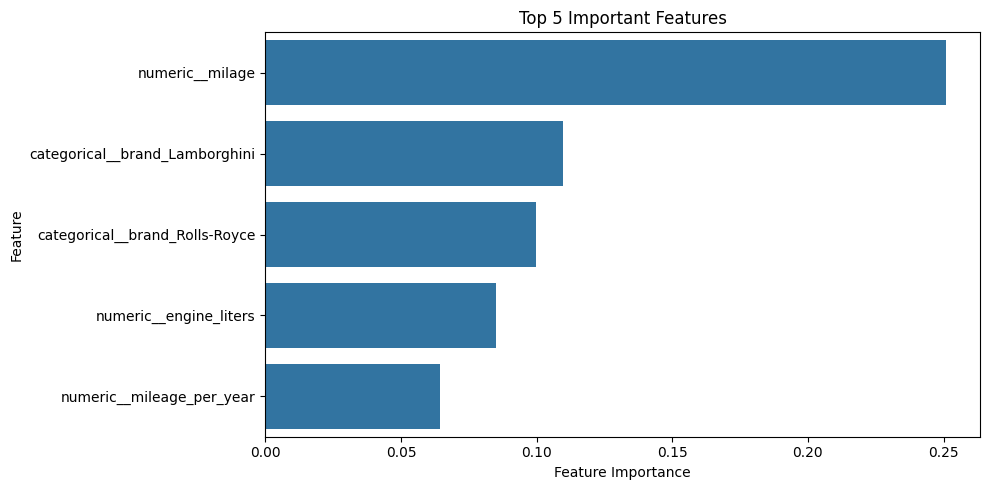

In [27]:
top_5 = importance_df.head(5)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_5,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 5 Important Features"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()


In [28]:
new_car = pd.DataFrame([{

    "brand": "Toyota",

    "model": "Camry",

    "model_year": 2021,

    "milage": 30000,

    "fuel_type": "Gasoline",

    "transmission": "Automatic",

    "ext_col": "White",

    "int_col": "Black",

    "accident": "None reported",

    "clean_title": "Yes",

    "car_age": 5,

    "engine_liters": 2.5,

    "mileage_per_year": 5000

}])


In [29]:
new_car_prediction = model.predict(
    new_car
)

In [30]:
print("\n========== NEW CAR PREDICTION ==========")

print(
    "Predicted Price: ₹",
    round(new_car_prediction[0], 2)
)


========== NEW CAR PREDICTION ==========
Predicted Price: ₹ 39588.09


In [31]:
import pickle

with open("used_car_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
